Epoch 001 | Train Acc: 66.57% | Val Acc: 78.02%
Epoch 002 | Train Acc: 78.72% | Val Acc: 76.25%
Epoch 003 | Train Acc: 83.81% | Val Acc: 87.72%
Epoch 004 | Train Acc: 86.45% | Val Acc: 87.74%
Epoch 005 | Train Acc: 88.37% | Val Acc: 89.12%
Epoch 006 | Train Acc: 89.42% | Val Acc: 90.91%
Epoch 007 | Train Acc: 90.62% | Val Acc: 92.39%
Epoch 008 | Train Acc: 91.74% | Val Acc: 94.37%
Epoch 009 | Train Acc: 92.65% | Val Acc: 86.02%
Epoch 010 | Train Acc: 93.44% | Val Acc: 94.48%
Epoch 011 | Train Acc: 93.96% | Val Acc: 92.45%
Epoch 012 | Train Acc: 94.03% | Val Acc: 93.59%
Epoch 013 | Train Acc: 94.42% | Val Acc: 93.50%
Epoch 014 | Train Acc: 94.79% | Val Acc: 95.27%
Epoch 015 | Train Acc: 95.50% | Val Acc: 96.29%
Epoch 016 | Train Acc: 94.93% | Val Acc: 95.11%
Epoch 017 | Train Acc: 95.59% | Val Acc: 97.32%
Epoch 018 | Train Acc: 95.53% | Val Acc: 96.60%
Epoch 019 | Train Acc: 96.16% | Val Acc: 95.77%
Epoch 020 | Train Acc: 96.08% | Val Acc: 96.64%
Epoch 021 | Train Acc: 96.10% | Val Acc:

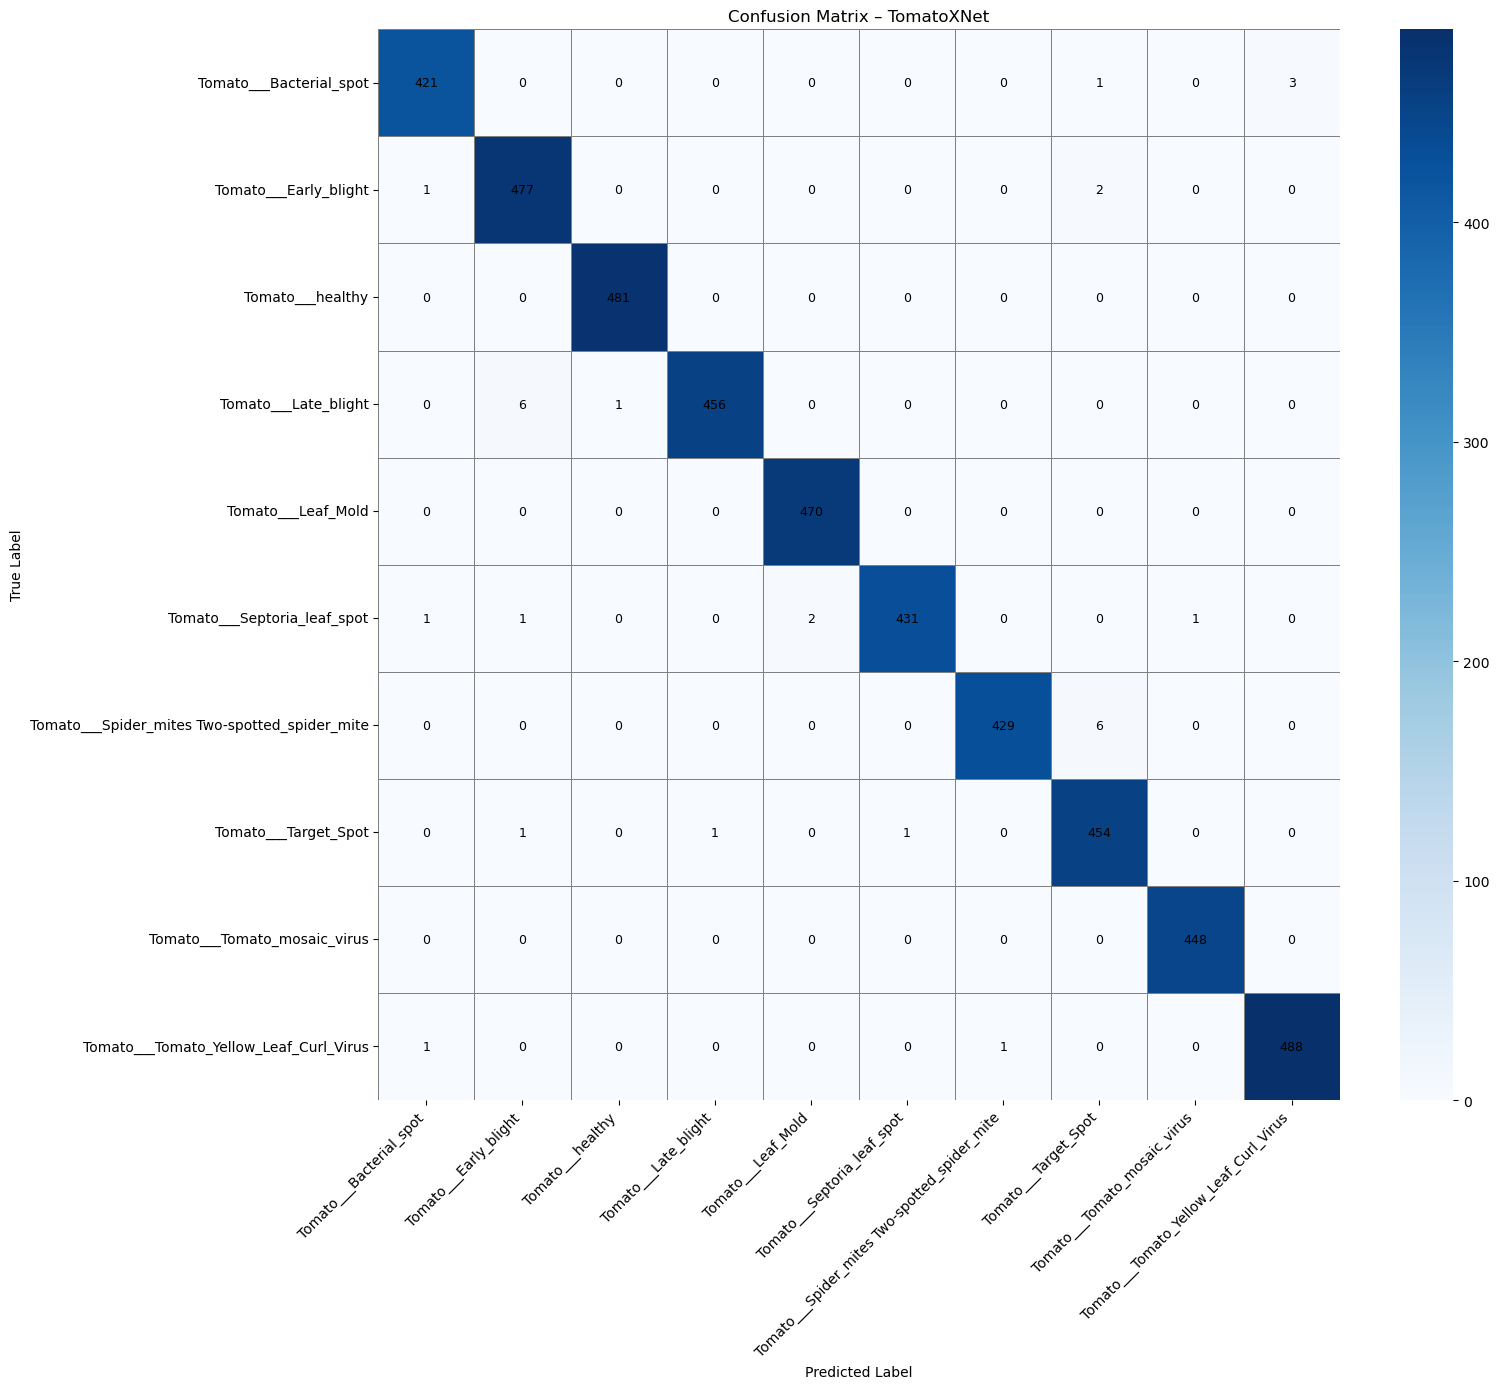

In [5]:
# =========================
# SINGLE CELL: TRAIN + EARLY STOPPING + CONFUSION MATRIX (TomatoXNet)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, recall_score

# -------------------------
# Dataset
# -------------------------
class PlantDataset(Dataset):
    def __init__(self, csv_file, label2idx, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.idx2label = {v: k for k, v in label2idx.items()}
        self.data["label_idx"] = self.data["class_label"].map(label2idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = Image.open(self.data.iloc[idx]["image_path"]).convert("RGB")
        label = self.data.iloc[idx]["label_idx"]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# TomatoXNet (Dropout = 0.3)
# -------------------------
class TomatoXNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.SiLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))

# -------------------------
# Transforms (Real-World Robust)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],   # ImageNet
        [0.229, 0.224, 0.225]
    )
])

# -------------------------
# Load Data
# -------------------------
train_csv = r"C:\RVR&JC\train_labels_tomato.csv"
valid_csv = r"C:\RVR&JC\valid_labels_tomato.csv"

train_df = pd.read_csv(train_csv)
label2idx = {l: i for i, l in enumerate(train_df["class_label"].unique())}
num_classes = len(label2idx)

train_ds = PlantDataset(train_csv, label2idx, transform)
valid_ds = PlantDataset(valid_csv, label2idx, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)

# -------------------------
# Model + Optimizer
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TomatoXNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# -------------------------
# Training with Early Stopping
# -------------------------
epochs = 100
patience = 10
best_acc = 0
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    scheduler.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = correct / total
    print(f"Epoch {epoch+1:03d} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    # Early stopping logic
    if val_acc > best_acc:
        best_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_tomatoxnet.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
            break

# -------------------------
# Final Evaluation
# -------------------------
model.load_state_dict(torch.load("best_tomatoxnet.pth"))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true, y_pred,
    target_names=[train_ds.idx2label[i] for i in range(num_classes)]
))

# -------------------------
# Overall Metrics
# -------------------------
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")

print("\n===== OVERALL METRICS =====")
print(f"Accuracy : {acc * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
ax = sns.heatmap(
    cm, cmap="Blues", cbar=True,
    xticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    yticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    linewidths=0.5, linecolor="gray"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha="center", va="center", fontsize=9)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – TomatoXNet")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [1]:
import torch
print(torch.__version__)


2.7.0+cu118


Epoch 001 | Train Acc: 65.71% | Val Acc: 74.33%
Epoch 002 | Train Acc: 77.80% | Val Acc: 82.79%
Epoch 003 | Train Acc: 83.05% | Val Acc: 85.80%
Epoch 004 | Train Acc: 86.31% | Val Acc: 85.93%
Epoch 005 | Train Acc: 87.90% | Val Acc: 86.17%
Epoch 006 | Train Acc: 89.23% | Val Acc: 89.33%
Epoch 007 | Train Acc: 90.34% | Val Acc: 93.52%
Epoch 008 | Train Acc: 91.43% | Val Acc: 92.87%
Epoch 009 | Train Acc: 92.15% | Val Acc: 94.92%
Epoch 010 | Train Acc: 92.92% | Val Acc: 93.57%
Epoch 011 | Train Acc: 92.84% | Val Acc: 94.63%
Epoch 012 | Train Acc: 94.07% | Val Acc: 94.44%
Epoch 013 | Train Acc: 94.10% | Val Acc: 90.88%
Epoch 014 | Train Acc: 94.49% | Val Acc: 95.86%
Epoch 015 | Train Acc: 94.77% | Val Acc: 96.29%
Epoch 016 | Train Acc: 95.19% | Val Acc: 94.59%
Epoch 017 | Train Acc: 95.42% | Val Acc: 96.38%
Epoch 018 | Train Acc: 95.78% | Val Acc: 96.62%
Epoch 019 | Train Acc: 95.74% | Val Acc: 95.73%
Epoch 020 | Train Acc: 96.27% | Val Acc: 97.03%
Epoch 021 | Train Acc: 96.29% | Val Acc:

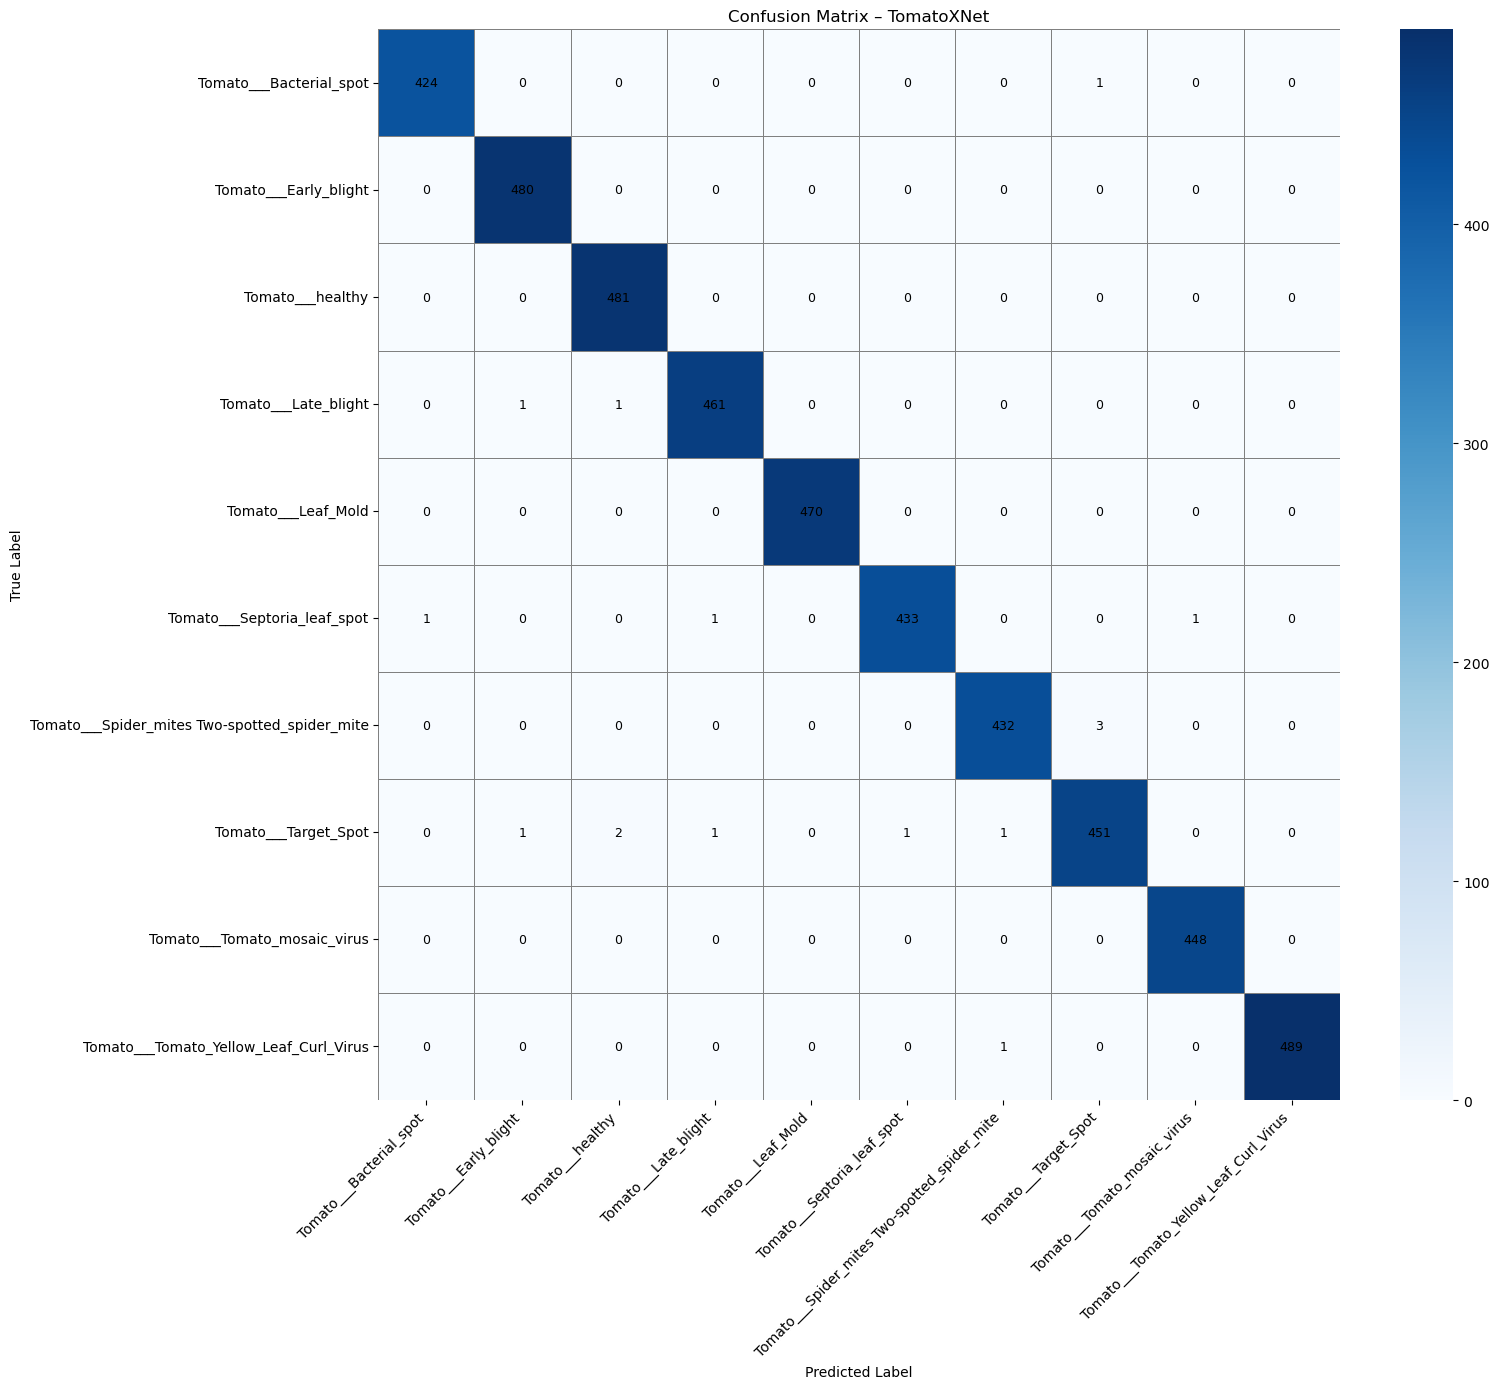

In [1]:
# =========================
# SINGLE CELL: TRAIN + EARLY STOPPING + CONFUSION MATRIX (TomatoXNet)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, recall_score

# -------------------------
# Dataset
# -------------------------
class PlantDataset(Dataset):
    def __init__(self, csv_file, label2idx, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.idx2label = {v: k for k, v in label2idx.items()}
        self.data["label_idx"] = self.data["class_label"].map(label2idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = Image.open(self.data.iloc[idx]["image_path"]).convert("RGB")
        label = self.data.iloc[idx]["label_idx"]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# TomatoXNet (Dropout = 0.3)
# -------------------------
class TomatoXNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.SiLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))

# -------------------------
# Transforms (Real-World Robust)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],   # ImageNet
        [0.229, 0.224, 0.225]
    )
])

# -------------------------
# Load Data
# -------------------------
train_csv = r"C:\RVR&JC\train_labels_tomato.csv"
valid_csv = r"C:\RVR&JC\valid_labels_tomato.csv"

train_df = pd.read_csv(train_csv)
label2idx = {l: i for i, l in enumerate(train_df["class_label"].unique())}
num_classes = len(label2idx)

train_ds = PlantDataset(train_csv, label2idx, transform)
valid_ds = PlantDataset(valid_csv, label2idx, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)

# -------------------------
# Model + Optimizer
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TomatoXNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# -------------------------
# Training with Early Stopping
# -------------------------
epochs = 100
patience = 10
best_acc = 0
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    scheduler.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = correct / total
    print(f"Epoch {epoch+1:03d} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    # Early stopping logic
    if val_acc > best_acc:
        best_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_tomatoxnet.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
            break

# -------------------------
# Final Evaluation
# -------------------------
model.load_state_dict(torch.load("best_tomatoxnet.pth"))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true, y_pred,
    target_names=[train_ds.idx2label[i] for i in range(num_classes)]
))

# -------------------------
# Overall Metrics
# -------------------------
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")

print("\n===== OVERALL METRICS =====")
print(f"Accuracy : {acc * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
ax = sns.heatmap(
    cm, cmap="Blues", cbar=True,
    xticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    yticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    linewidths=0.5, linecolor="gray"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha="center", va="center", fontsize=9)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – TomatoXNet")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Epoch 001 | Train Acc: 65.83% | Val Acc: 69.84%
Epoch 002 | Train Acc: 78.69% | Val Acc: 80.81%
Epoch 003 | Train Acc: 83.39% | Val Acc: 84.60%
Epoch 004 | Train Acc: 86.31% | Val Acc: 87.55%
Epoch 005 | Train Acc: 87.82% | Val Acc: 88.35%
Epoch 006 | Train Acc: 89.11% | Val Acc: 79.11%
Epoch 007 | Train Acc: 90.11% | Val Acc: 92.78%
Epoch 008 | Train Acc: 91.32% | Val Acc: 93.33%
Epoch 009 | Train Acc: 92.03% | Val Acc: 89.36%
Epoch 010 | Train Acc: 92.23% | Val Acc: 92.67%
Epoch 011 | Train Acc: 93.20% | Val Acc: 95.88%
Epoch 012 | Train Acc: 93.77% | Val Acc: 94.79%
Epoch 013 | Train Acc: 94.33% | Val Acc: 95.40%
Epoch 014 | Train Acc: 94.51% | Val Acc: 94.11%
Epoch 015 | Train Acc: 94.83% | Val Acc: 93.72%
Epoch 016 | Train Acc: 94.73% | Val Acc: 91.80%
Epoch 017 | Train Acc: 95.12% | Val Acc: 96.01%
Epoch 018 | Train Acc: 95.45% | Val Acc: 95.94%
Epoch 019 | Train Acc: 95.84% | Val Acc: 94.70%
Epoch 020 | Train Acc: 95.62% | Val Acc: 96.51%
Epoch 021 | Train Acc: 96.19% | Val Acc:

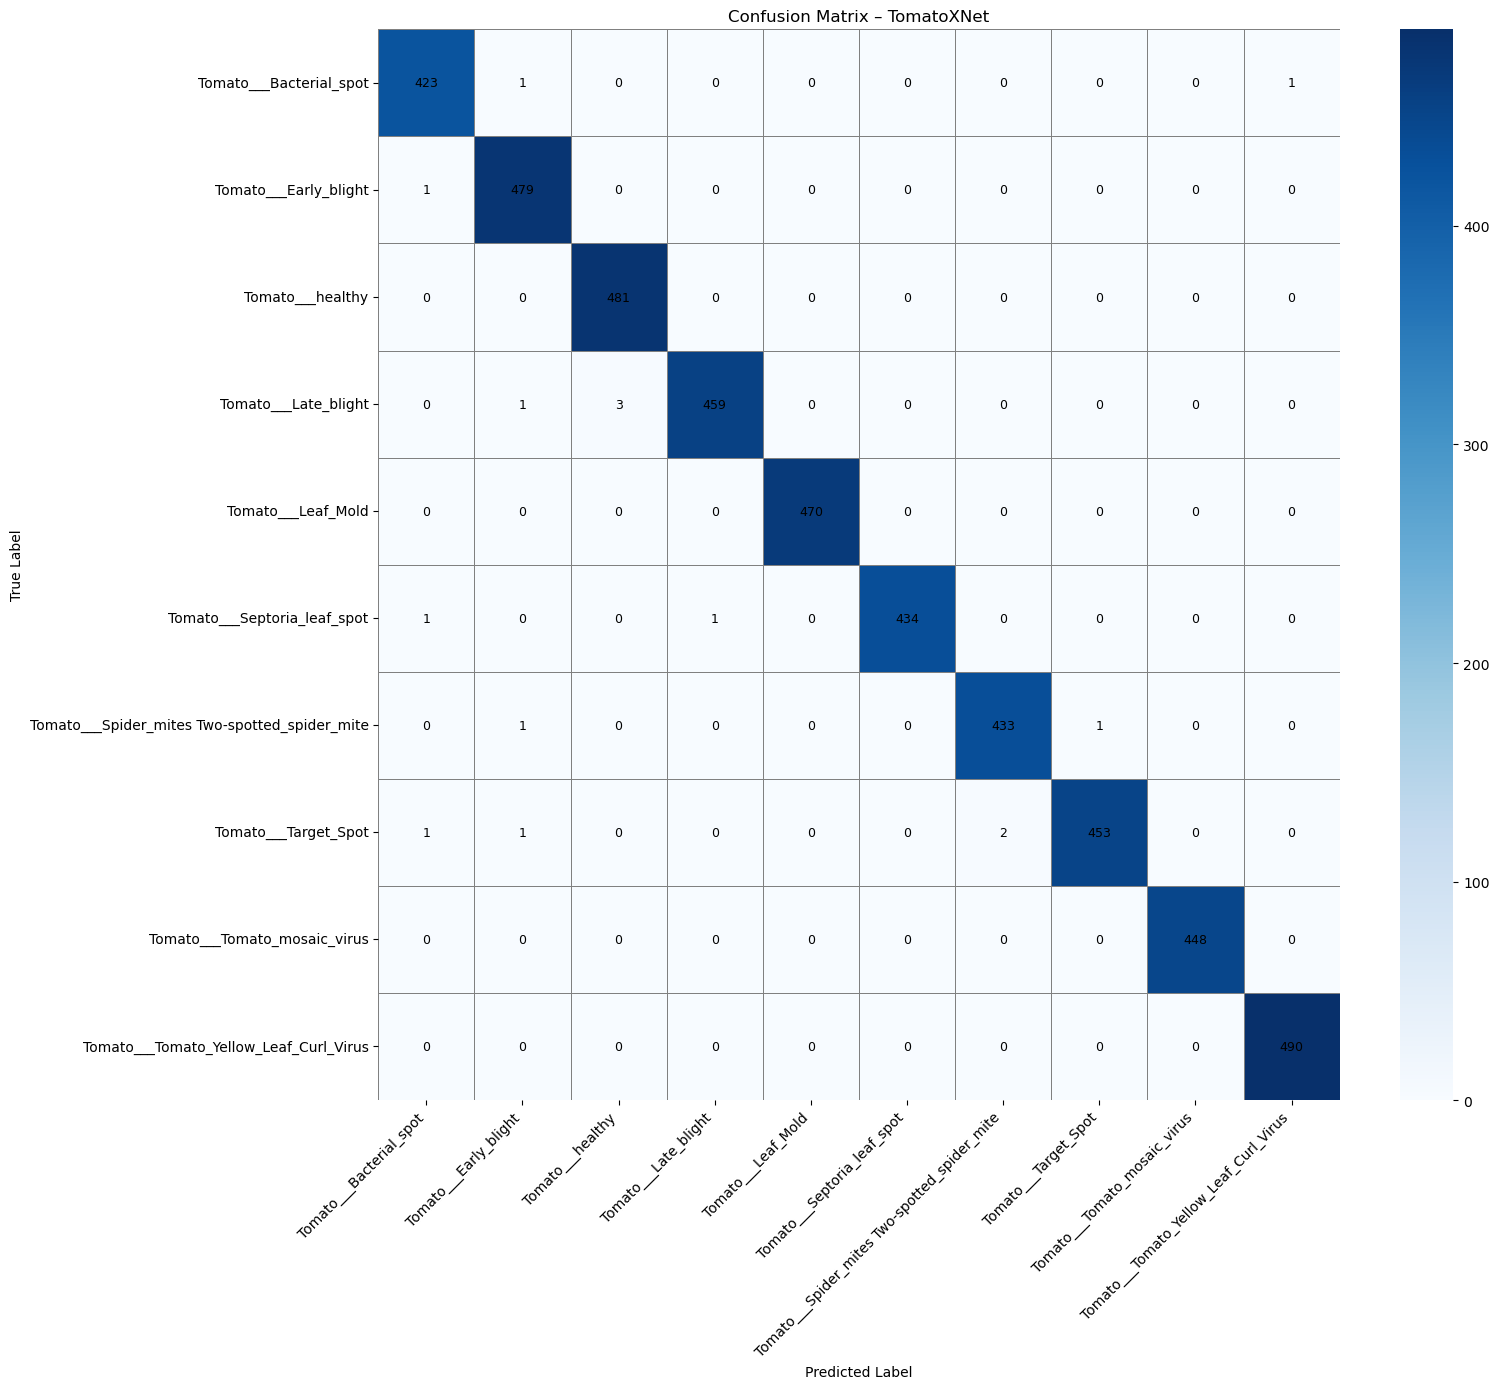

In [1]:
# =========================
# SINGLE CELL: TRAIN + EARLY STOPPING + CONFUSION MATRIX (TomatoXNet)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, recall_score

# -------------------------
# Dataset
# -------------------------
class PlantDataset(Dataset):
    def __init__(self, csv_file, label2idx, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.idx2label = {v: k for k, v in label2idx.items()}
        self.data["label_idx"] = self.data["class_label"].map(label2idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = Image.open(self.data.iloc[idx]["image_path"]).convert("RGB")
        label = self.data.iloc[idx]["label_idx"]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# TomatoXNet (Dropout = 0.3)
# -------------------------
class TomatoXNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.SiLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))

# -------------------------
# Transforms (Real-World Robust)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],   # ImageNet
        [0.229, 0.224, 0.225]
    )
])

# -------------------------
# Load Data
# -------------------------
train_csv = r"C:\RVR&JC\train_labels_tomato.csv"
valid_csv = r"C:\RVR&JC\valid_labels_tomato.csv"

train_df = pd.read_csv(train_csv)
label2idx = {l: i for i, l in enumerate(train_df["class_label"].unique())}
num_classes = len(label2idx)

train_ds = PlantDataset(train_csv, label2idx, transform)
valid_ds = PlantDataset(valid_csv, label2idx, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)

# -------------------------
# Model + Optimizer
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TomatoXNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# -------------------------
# Training with Early Stopping
# -------------------------
epochs = 100
patience = 10
best_acc = 0
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    scheduler.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = correct / total
    print(f"Epoch {epoch+1:03d} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    # Early stopping logic
    if val_acc > best_acc:
        best_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_tomatoxnet.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
            break

# -------------------------
# Final Evaluation
# -------------------------
model.load_state_dict(torch.load("best_tomatoxnet.pth"))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true, y_pred,
    target_names=[train_ds.idx2label[i] for i in range(num_classes)]
))

# -------------------------
# Overall Metrics
# -------------------------
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")

print("\n===== OVERALL METRICS =====")
print(f"Accuracy : {acc * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
ax = sns.heatmap(
    cm, cmap="Blues", cbar=True,
    xticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    yticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    linewidths=0.5, linecolor="gray"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha="center", va="center", fontsize=9)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – TomatoXNet")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Epoch 001 | Train Acc: 65.74% | Val Acc: 78.63%
Epoch 002 | Train Acc: 78.65% | Val Acc: 81.13%
Epoch 003 | Train Acc: 83.59% | Val Acc: 80.22%
Epoch 004 | Train Acc: 86.11% | Val Acc: 85.61%
Epoch 005 | Train Acc: 88.01% | Val Acc: 88.38%
Epoch 006 | Train Acc: 89.46% | Val Acc: 89.55%
Epoch 007 | Train Acc: 90.22% | Val Acc: 92.82%
Epoch 008 | Train Acc: 91.67% | Val Acc: 93.46%
Epoch 009 | Train Acc: 91.58% | Val Acc: 92.43%
Epoch 010 | Train Acc: 92.70% | Val Acc: 94.83%
Epoch 011 | Train Acc: 93.67% | Val Acc: 93.20%
Epoch 012 | Train Acc: 93.83% | Val Acc: 93.44%
Epoch 013 | Train Acc: 94.09% | Val Acc: 95.46%
Epoch 014 | Train Acc: 94.57% | Val Acc: 96.42%
Epoch 015 | Train Acc: 94.72% | Val Acc: 96.47%
Epoch 016 | Train Acc: 95.52% | Val Acc: 96.40%
Epoch 017 | Train Acc: 95.42% | Val Acc: 96.86%
Epoch 018 | Train Acc: 95.61% | Val Acc: 96.21%
Epoch 019 | Train Acc: 96.02% | Val Acc: 96.58%
Epoch 020 | Train Acc: 95.84% | Val Acc: 96.95%
Epoch 021 | Train Acc: 96.41% | Val Acc:

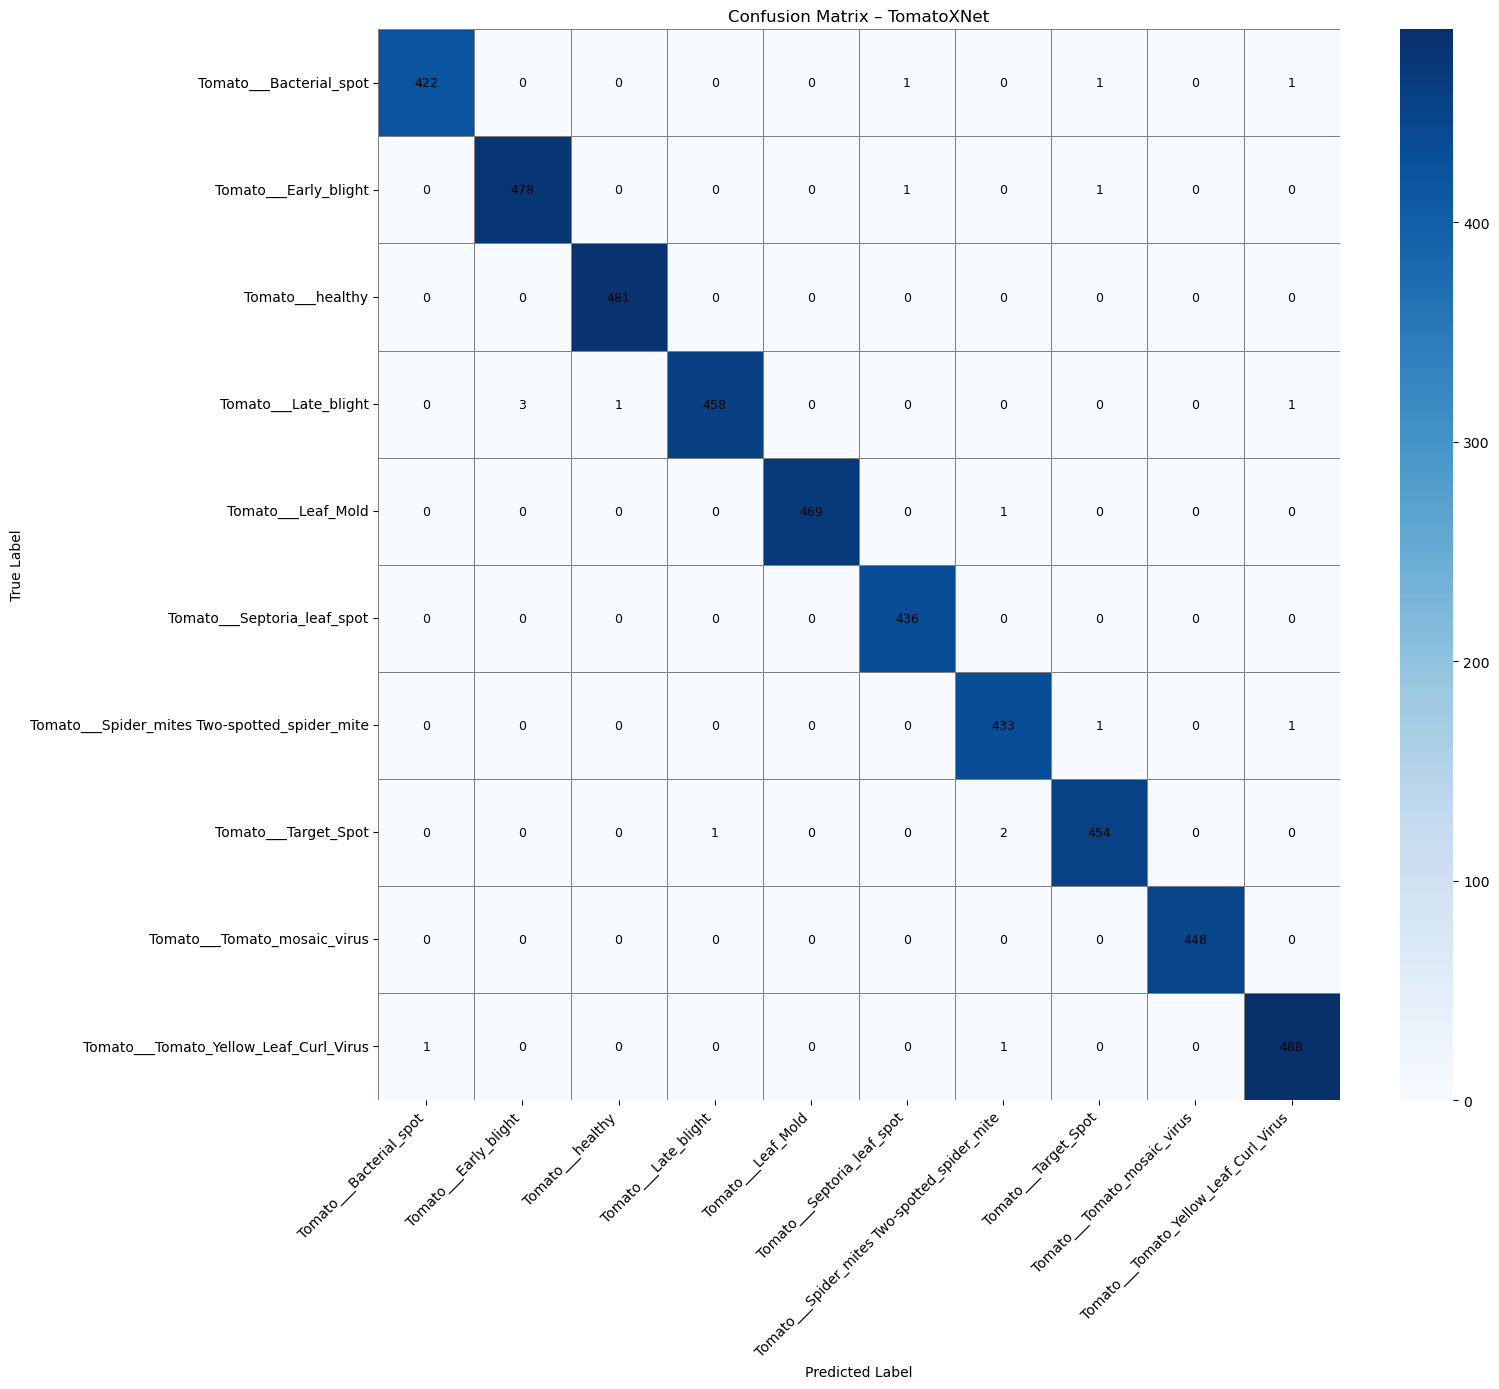

In [1]:
# =========================
# SINGLE CELL: TRAIN + EARLY STOPPING + CONFUSION MATRIX (TomatoXNet)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, recall_score

# -------------------------
# Dataset
# -------------------------
class PlantDataset(Dataset):
    def __init__(self, csv_file, label2idx, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.idx2label = {v: k for k, v in label2idx.items()}
        self.data["label_idx"] = self.data["class_label"].map(label2idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = Image.open(self.data.iloc[idx]["image_path"]).convert("RGB")
        label = self.data.iloc[idx]["label_idx"]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# TomatoXNet (Dropout = 0.3)
# -------------------------
class TomatoXNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.SiLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))

# -------------------------
# Transforms (Real-World Robust)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],   # ImageNet
        [0.229, 0.224, 0.225]
    )
])

# -------------------------
# Load Data
# -------------------------
train_csv = r"C:\RVR&JC\train_labels_tomato.csv"
valid_csv = r"C:\RVR&JC\valid_labels_tomato.csv"

train_df = pd.read_csv(train_csv)
label2idx = {l: i for i, l in enumerate(train_df["class_label"].unique())}
num_classes = len(label2idx)

train_ds = PlantDataset(train_csv, label2idx, transform)
valid_ds = PlantDataset(valid_csv, label2idx, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)

# -------------------------
# Model + Optimizer
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TomatoXNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# -------------------------
# Training with Early Stopping
# -------------------------
epochs = 100
patience = 10
best_acc = 0
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    scheduler.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = correct / total
    print(f"Epoch {epoch+1:03d} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    # Early stopping logic
    if val_acc > best_acc:
        best_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_tomatoxnet.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
            break

# -------------------------
# Final Evaluation
# -------------------------
model.load_state_dict(torch.load("best_tomatoxnet.pth"))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true, y_pred,
    target_names=[train_ds.idx2label[i] for i in range(num_classes)]
))

# -------------------------
# Overall Metrics
# -------------------------
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")

print("\n===== OVERALL METRICS =====")
print(f"Accuracy : {acc * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
ax = sns.heatmap(
    cm, cmap="Blues", cbar=True,
    xticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    yticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    linewidths=0.5, linecolor="gray"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha="center", va="center", fontsize=9)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – TomatoXNet")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Epoch 001 | Train Acc: 65.86% | Val Acc: 70.60%
Epoch 002 | Train Acc: 78.11% | Val Acc: 81.05%
Epoch 003 | Train Acc: 82.57% | Val Acc: 85.58%
Epoch 004 | Train Acc: 85.37% | Val Acc: 88.64%
Epoch 005 | Train Acc: 87.24% | Val Acc: 85.65%
Epoch 006 | Train Acc: 88.97% | Val Acc: 88.35%
Epoch 007 | Train Acc: 90.07% | Val Acc: 89.36%
Epoch 008 | Train Acc: 90.66% | Val Acc: 93.46%
Epoch 009 | Train Acc: 91.69% | Val Acc: 92.58%
Epoch 010 | Train Acc: 92.35% | Val Acc: 94.35%
Epoch 011 | Train Acc: 92.85% | Val Acc: 92.87%
Epoch 012 | Train Acc: 93.46% | Val Acc: 95.29%
Epoch 013 | Train Acc: 93.76% | Val Acc: 94.42%
Epoch 014 | Train Acc: 94.35% | Val Acc: 96.18%
Epoch 015 | Train Acc: 94.95% | Val Acc: 96.05%
Epoch 016 | Train Acc: 94.87% | Val Acc: 94.77%
Epoch 017 | Train Acc: 95.16% | Val Acc: 95.59%
Epoch 018 | Train Acc: 95.69% | Val Acc: 97.34%
Epoch 019 | Train Acc: 96.01% | Val Acc: 96.99%
Epoch 020 | Train Acc: 95.94% | Val Acc: 96.68%
Epoch 021 | Train Acc: 96.06% | Val Acc:

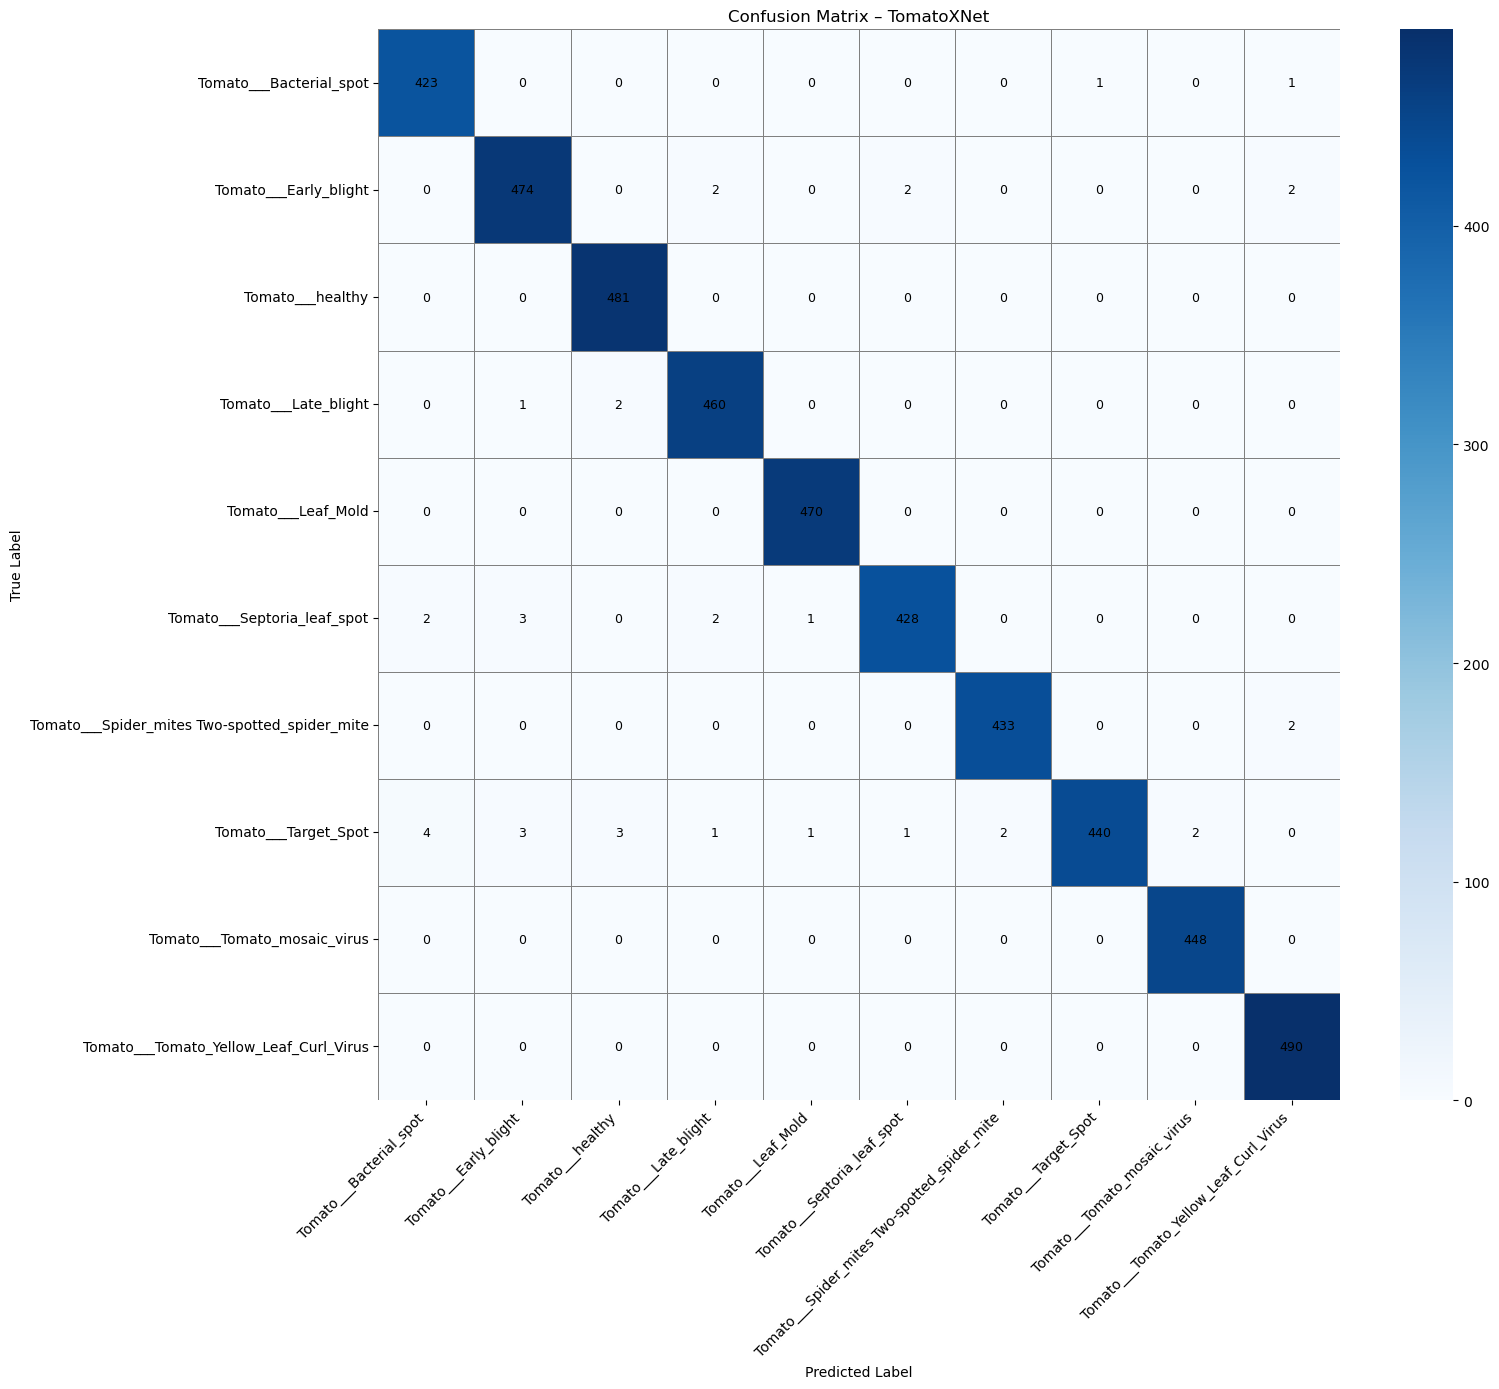

In [1]:
# =========================
# SINGLE CELL: TRAIN + EARLY STOPPING + CONFUSION MATRIX (TomatoXNet)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, recall_score

# -------------------------
# Dataset
# -------------------------
class PlantDataset(Dataset):
    def __init__(self, csv_file, label2idx, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.idx2label = {v: k for k, v in label2idx.items()}
        self.data["label_idx"] = self.data["class_label"].map(label2idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = Image.open(self.data.iloc[idx]["image_path"]).convert("RGB")
        label = self.data.iloc[idx]["label_idx"]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# TomatoXNet (Dropout = 0.3)
# -------------------------
class TomatoXNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.SiLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))

# -------------------------
# Transforms (Real-World Robust)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],   # ImageNet
        [0.229, 0.224, 0.225]
    )
])

# -------------------------
# Load Data
# -------------------------
train_csv = r"C:\RVR&JC\train_labels_tomato.csv"
valid_csv = r"C:\RVR&JC\valid_labels_tomato.csv"

train_df = pd.read_csv(train_csv)
label2idx = {l: i for i, l in enumerate(train_df["class_label"].unique())}
num_classes = len(label2idx)

train_ds = PlantDataset(train_csv, label2idx, transform)
valid_ds = PlantDataset(valid_csv, label2idx, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)

# -------------------------
# Model + Optimizer
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TomatoXNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# -------------------------
# Training with Early Stopping
# -------------------------
epochs = 100
patience = 10
best_acc = 0
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    scheduler.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_acc = correct / total
    print(f"Epoch {epoch+1:03d} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    # Early stopping logic
    if val_acc > best_acc:
        best_acc = val_acc
        early_stop_counter = 0
        torch.save(model.state_dict(), "best_tomatoxnet.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
            break

# -------------------------
# Final Evaluation
# -------------------------
model.load_state_dict(torch.load("best_tomatoxnet.pth"))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true, y_pred,
    target_names=[train_ds.idx2label[i] for i in range(num_classes)]
))

# -------------------------
# Overall Metrics
# -------------------------
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")

print("\n===== OVERALL METRICS =====")
print(f"Accuracy : {acc * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
ax = sns.heatmap(
    cm, cmap="Blues", cbar=True,
    xticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    yticklabels=[train_ds.idx2label[i] for i in range(num_classes)],
    linewidths=0.5, linecolor="gray"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, cm[i, j],
                ha="center", va="center", fontsize=9)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – TomatoXNet")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


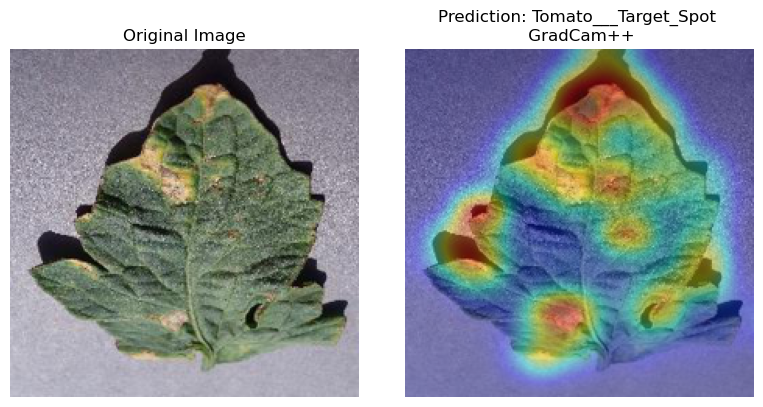

In [2]:
# =========================
# GRAD-CAM++ VISUALIZATION (TomatoXNet)
# =========================

import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import pandas as pd

# -------------------------
# Label mapping
# -------------------------
train_csv = r"C:\RVR&JC\train_labels_tomato.csv"
train_df = pd.read_csv(train_csv)
label2idx = {l: i for i, l in enumerate(train_df["class_label"].unique())}
idx2label = {v: k for k, v in label2idx.items()}
num_classes = len(label2idx)

# -------------------------
# Load trained model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TomatoXNet(num_classes).to(device)
model.load_state_dict(torch.load("best_tomatoxnet.pth", map_location=device))
model.eval()

# -------------------------
# Image transform (NO augmentation)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# -------------------------
# Load image
# -------------------------
image_path = r"C:\RVR&JC\Test_images\tar2.JPG"   # 🔴 change this
original_img = Image.open(image_path).convert("RGB")
input_tensor = transform(original_img).unsqueeze(0).to(device)

# -------------------------
# Hooks
# -------------------------
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Last conv block (before GAP)
target_layer = model.features[-2]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# -------------------------
# Forward + backward
# -------------------------
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

model.zero_grad()
output[0, pred_class].backward(retain_graph=True)

# -------------------------
# Grad-CAM++ computation
# -------------------------
grads = gradients[0][0]        # [C, H, W]
acts = activations[0][0]       # [C, H, W]

# α coefficients
grads_power_2 = grads ** 2
grads_power_3 = grads ** 3

sum_acts = acts.sum(dim=(1, 2), keepdim=True)

eps = 1e-8
alpha = grads_power_2 / (2 * grads_power_2 + sum_acts * grads_power_3 + eps)

# Weights
positive_grads = F.relu(grads)
weights = (alpha * positive_grads).sum(dim=(1, 2))

# CAM
cam = torch.zeros(acts.shape[1:], device=device)
for i, w in enumerate(weights):
    cam += w * acts[i]

cam = F.relu(cam)
cam = cam.cpu().detach().numpy()

# Resize
cam = cv2.resize(cam, (224, 224))

# -------------------------
# SMOOTHING
# -------------------------
cam = cv2.GaussianBlur(cam, (21, 21), sigmaX=8)
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# -------------------------
# Overlay
# -------------------------
img_np = np.array(original_img.resize((224, 224)))

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

overlay = cv2.addWeighted(img_np, 0.65, heatmap, 0.35, 0)

# -------------------------
# Display
# -------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

#plt.subplot(1, 3, 2)
#plt.imshow(cam, cmap="jet")
#plt.title("Grad-CAM++")
#plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(overlay)
plt.title(f"Prediction: {idx2label[pred_class]} \n GradCam++")
plt.axis("off")

plt.tight_layout()
plt.show()


In [93]:
# =========================
# MODEL COMPARISON WITH ACCURACY, RECALL, F1
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score

# -------------------------
# Dataset
# -------------------------
class PlantDataset(Dataset):
    def __init__(self, csv_file, label2idx, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label2idx = label2idx
        self.data["label_idx"] = self.data["class_label"].map(label2idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = Image.open(self.data.iloc[idx]["image_path"]).convert("RGB")
        label = self.data.iloc[idx]["label_idx"]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# Transforms (ImageNet)
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# -------------------------
# Load Data
# -------------------------
train_csv = r"C:\RVR&JC\train_labels_tomato.csv"
valid_csv = r"C:\RVR&JC\valid_labels_tomato.csv"

train_df = pd.read_csv(train_csv)
label2idx = {l: i for i, l in enumerate(train_df["class_label"].unique())}
num_classes = len(label2idx)

train_ds = PlantDataset(train_csv, label2idx, transform)
valid_ds = PlantDataset(valid_csv, label2idx, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Model Factory
# -------------------------
def get_model(name, num_classes):
    if name == "efficientnet_b0":
        model = models.efficientnet_b0(weights="IMAGENET1K_V1")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif name == "resnet50":
        model = models.resnet50(weights="IMAGENET1K_V1")
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "mobilenet_v2":
        model = models.mobilenet_v2(weights="IMAGENET1K_V1")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif name == "convnext_tiny":
        model = models.convnext_tiny(weights="IMAGENET1K_V1")
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

    return model.to(device)

# -------------------------
# Training + Early Stopping
# -------------------------
def train_model(model, name, epochs=50, patience=7):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    best_acc = 0
    stop_counter = 0

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x).argmax(1)
                y_true.extend(y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        acc = accuracy_score(y_true, y_pred)

        print(f"{name.upper()} | Epoch {epoch+1:02d} | Acc: {acc*100:.2f}%")

        if acc > best_acc:
            best_acc = acc
            best_preds = y_pred.copy()
            best_true = y_true.copy()
            stop_counter = 0
        else:
            stop_counter += 1
            if stop_counter >= patience:
                print(f"⛔ Early stopping {name.upper()} at epoch {epoch+1}\n")
                break

    recall = recall_score(best_true, best_preds, average="weighted")
    f1 = f1_score(best_true, best_preds, average="weighted")

    return best_acc, recall, f1

# -------------------------
# Run Comparison
# -------------------------
models_list = [
    "efficientnet_b0",
    "resnet50",
    "mobilenet_v2",
    "convnext_tiny"
]

results = {}

for m in models_list:
    print(f"\n🚀 Training {m.upper()}")
    model = get_model(m, num_classes)
    acc, recall, f1 = train_model(model, m)
    results[m] = (acc, recall, f1)

# -------------------------
# Final Results
# -------------------------
print("\n===== FINAL COMPARISON RESULTS =====")
print(f"{'MODEL':20s} {'ACC (%)':>10s} {'RECALL (%)':>12s} {'F1 (%)':>10s}")

for k, (acc, recall, f1) in results.items():
    print(f"{k.upper():20s} {acc*100:10.2f} {recall*100:12.2f} {f1*100:10.2f}")



🚀 Training EFFICIENTNET_B0
EFFICIENTNET_B0 | Epoch 01 | Acc: 96.62%
EFFICIENTNET_B0 | Epoch 02 | Acc: 91.73%
EFFICIENTNET_B0 | Epoch 03 | Acc: 98.52%
EFFICIENTNET_B0 | Epoch 04 | Acc: 99.26%
EFFICIENTNET_B0 | Epoch 05 | Acc: 98.15%
EFFICIENTNET_B0 | Epoch 06 | Acc: 98.39%
EFFICIENTNET_B0 | Epoch 07 | Acc: 99.61%
EFFICIENTNET_B0 | Epoch 08 | Acc: 99.32%
EFFICIENTNET_B0 | Epoch 09 | Acc: 99.54%
EFFICIENTNET_B0 | Epoch 10 | Acc: 98.82%
EFFICIENTNET_B0 | Epoch 11 | Acc: 97.99%
EFFICIENTNET_B0 | Epoch 12 | Acc: 98.91%
EFFICIENTNET_B0 | Epoch 13 | Acc: 99.76%
EFFICIENTNET_B0 | Epoch 14 | Acc: 99.41%
EFFICIENTNET_B0 | Epoch 15 | Acc: 99.32%
EFFICIENTNET_B0 | Epoch 16 | Acc: 98.97%
EFFICIENTNET_B0 | Epoch 17 | Acc: 98.84%
EFFICIENTNET_B0 | Epoch 18 | Acc: 99.65%
EFFICIENTNET_B0 | Epoch 19 | Acc: 99.41%
EFFICIENTNET_B0 | Epoch 20 | Acc: 98.91%
⛔ Early stopping EFFICIENTNET_B0 at epoch 20


🚀 Training RESNET50
RESNET50 | Epoch 01 | Acc: 92.69%
RESNET50 | Epoch 02 | Acc: 95.59%
RESNET50 | Epoch 

In [95]:
# SINGLE CELL: MODEL PARAMETERS
# =========================

import torch
import torch.nn as nn
from torchvision.models import (
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights
)

# -------------------------
# TomatoXNet (Proposed)
# -------------------------
class TomatoXNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.SiLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.SiLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1))


# -------------------------
# Parameter Counter
# -------------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6


# -------------------------
# Initialize Models
# -------------------------
num_classes = 10

models = {
    "ResNet50": resnet50(weights=ResNet50_Weights.IMAGENET1K_V1),
    "MobileNetV2": mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1),
    "EfficientNet-B0": efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1),
    "ConvNeXt-Tiny": convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1),
    "TomatoXNet (Proposed)": TomatoXNet(num_classes)
}

# -------------------------
# Replace Classifiers (Fair Comparison)
# -------------------------
models["ResNet50"].fc = nn.Linear(2048, num_classes)
models["MobileNetV2"].classifier[1] = nn.Linear(1280, num_classes)
models["EfficientNet-B0"].classifier[1] = nn.Linear(1280, num_classes)
models["ConvNeXt-Tiny"].classifier[2] = nn.Linear(768, num_classes)

# -------------------------
# Print Parameters
# -------------------------
print("Model Parameters (in Millions):\n")
for name, model in models.items():
    print(f"{name:<22}: {count_params(model):.2f} M")

Model Parameters (in Millions):

ResNet50              : 23.53 M
MobileNetV2           : 2.24 M
EfficientNet-B0       : 4.02 M
ConvNeXt-Tiny         : 27.83 M
TomatoXNet (Proposed) : 1.18 M


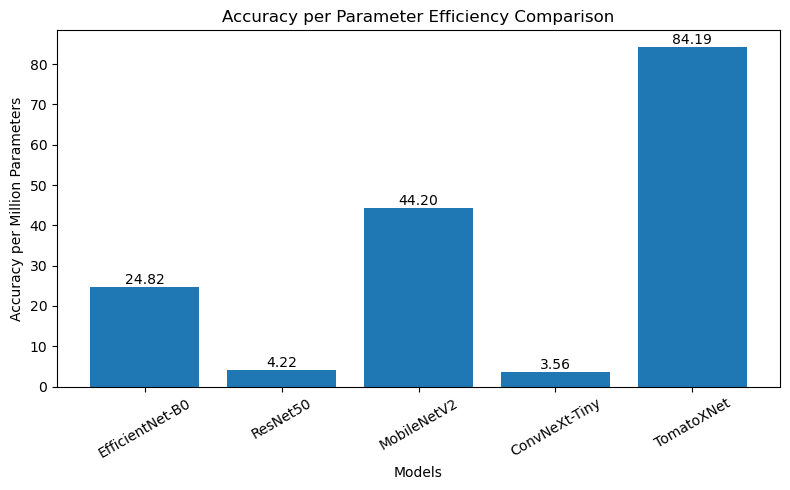

In [2]:
import matplotlib.pyplot as plt

models = [
    "EfficientNet-B0",
    "ResNet50",
    "MobileNetV2",
    "ConvNeXt-Tiny",
    "TomatoXNet"
]

accuracy = [99.76, 99.24, 99.00, 99.00, 99.35]
parameters_m = [4.02, 23.53, 2.24, 27.83, 1.18]

accuracy_per_param = [
    acc / param for acc, param in zip(accuracy, parameters_m)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracy_per_param)

plt.xlabel("Models")
plt.ylabel("Accuracy per Million Parameters")
plt.title("Accuracy per Parameter Efficiency Comparison")
plt.xticks(rotation=30)

# ---- ADD VALUES ON TOP OF BARS ----
for bar, value in zip(bars, accuracy_per_param):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()
